In [12]:
# 差の変数を d = new - year2（待受時間の減少量）とする。
#
# - **帰無仮説 H₀**: μd = 20（平均減少量は20時間である。つまりバッテリー容量は2年間で1割減少する）
# - **対立仮説 H₁**: μd ≠ 20（平均減少量は20時間ではない。つまり1割減少とは言えない）

In [1]:
# 必要なライブラリをimport
import numpy as np
import seaborn as sns
import pandas as pd
import random

sns.set_theme()

In [14]:
# データを読み込む
data = pd.read_csv('batteries_hours.csv')

In [6]:
# 先頭の5行を表示
data.head()

,new,year2
0,200.614633,181.027960
1,199.716863,164.124190
2,205.733141,171.638352
3,193.768958,174.801830
4,206.248877,198.362352


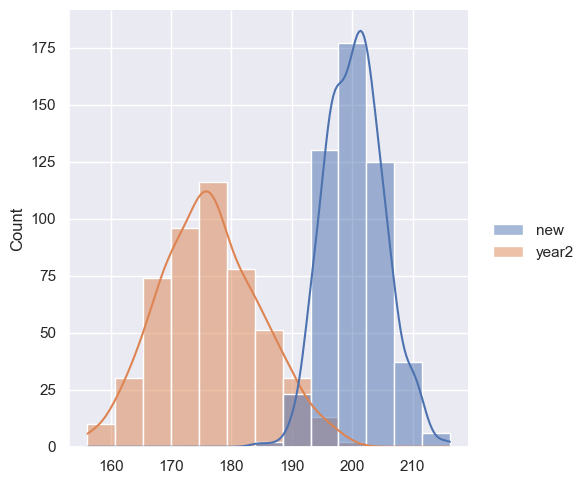

In [23]:
import matplotlib.pyplot as plt
# new と year2 のヒストグラムと分布
data2 = pd.DataFrame(columns=['new', 'year2'])
data2['new'] = data['new']
data2['year2'] = data['year2']
sns.displot(data2, kde=True)
plt.show()

In [25]:
from scipy import stats
# new の母平均の推定値
mu_new = np.mean(data['new'])
print(f"new の母平均の推定値: {mu_new}")

# new の95%信頼区間
n = len(data['new'])
se_new = stats.sem(data['new'])
ci_new = stats.t.interval(0.95, df=n-1, loc=mu_new, scale=se_new)
print(f"new の95%信頼区間 下限値: {ci_new[0]}")
print(f"new の95%信頼区間 上限値: {ci_new[1]}")

new の母平均の推定値: 200.4746372262155
new の95%信頼区間 下限値: 200.0533518842937
new の95%信頼区間 上限値: 200.89592256813728


In [26]:
# year2 の母平均の推定値
mu_year2 = np.mean(data['year2'])
print(f"year2 の母平均の推定値: {mu_year2}")

# year2 の95%信頼区間
se_year2 = stats.sem(data['year2'])
ci_year2 = stats.t.interval(0.95, df=n-1, loc=mu_year2, scale=se_year2)
print(f"year2 の95%信頼区間 下限値: {ci_year2[0]}")
print(f"year2 の95%信頼区間 上限値: {ci_year2[1]}")

year2 の母平均の推定値: 176.4021507111103
year2 の95%信頼区間 下限値: 175.67364051788374
year2 の95%信頼区間 上限値: 177.13066090433685


In [27]:
# %% 差の計算
data['diff'] = data['new'] - data['year2']

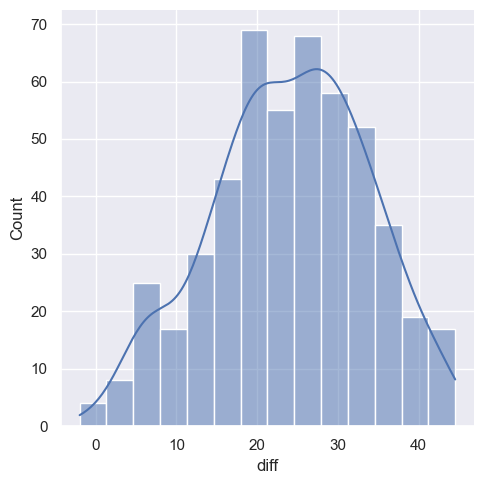

In [28]:
# ヒストグラムと確率分布を描画
sns.displot(data['diff'], kde=True)

In [31]:
# 差の平均
mu_diff = np.mean(data['diff'])
print(f"差の平均: {mu_diff}")

差の平均: 24.072486515105183


In [32]:
# 差の標準誤差
se_diff = stats.sem(data['diff'])
print(f"差の標準誤差: {se_diff}")

差の標準誤差: 0.4302555418829919


In [33]:
# t値の計算（帰無仮説: μd = 20）
t_value = (mu_diff - 20) / se_diff
print(f"t値: {t_value}")

t値: 9.465273816769795


In [35]:
# p値の計算（両側検定）
p_value = stats.t.sf(abs(t_value), df=n-1) * 2
print(f"p値: {p_value}")

p値: 1.1594662512929255e-19


In [36]:
# 判定
alpha = 0.05
if p_value < alpha:
    print(f"p値 ({p_value}) < α ({alpha}) のため、帰無仮説を棄却する。")
else:
    print(f"p値 ({p_value}) >= α ({alpha}) のため、帰無仮説を棄却できない。")

p値 (1.1594662512929255e-19) < α (0.05) のため、帰無仮説を棄却する。


## 検定結果の判断


- p値 < 0.05 の場合：帰無仮説を棄却する。平均減少量は20時間とは言えず、「2年間で1割程度しか減少しない」という主張は統計的に支持されない。